In [ ]:
# [Cell 20: The V4 Master Ensemble - Poisson + Baseline Weighted Training]
import lightgbm as lgb
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import mean_absolute_error

# 1. SETUP DATA
# We ensure the columns match the output from the new Cell 2
X_v4 = windowed_df.drop(columns=['target'])
y_v4 = windowed_df['target'].copy()

# Poisson cannot handle negative labels (red cards/conceding)
y_v4_clipped = np.maximum(y_v4, 0)

# 2. WEIGHTED TRAINING (Star-Priority)
# We give 2.5x importance to high-scoring matches (8+) 
# to help the model learn the "peaks" of elite players.
weights = np.where(y_v4_clipped >= 8, 2.5, 1.0) 

# 3. POISSON REGRESSION PARAMETERS
lgbm_v4_params = {
    'objective': 'poisson',
    'n_estimators': 1200,
    'learning_rate': 0.01,
    'reg_alpha': 0.3, # L1 Regularization to prevent noise
    'reg_lambda': 0.3, # L2 Regularization
    'importance_type': 'gain',
    'verbosity': -1,
    'random_state': 42
}

model_v4 = lgb.LGBMRegressor(**lgbm_v4_params)

print(f"Training V4 Poisson Ensemble with Season Baseline...")
print(f"Features in use: {list(X_v4.columns)}")

# 4. FIT MODEL
model_v4.fit(
    X_v4, y_v4_clipped, 
    sample_weight=weights,
    categorical_feature=['position', 'next_is_home']
)

# 5. SAVE V4 ARTIFACTS
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
model_v4.booster_.save_model(str(V4_DIR / 'fpl_pro_model_v4.txt'))

# 6. DIAGNOSTIC PERFORMANCE
y_pred_v4 = model_v4.predict(X_v4)
print(f"\nV4 Performance Audit:")
print(f"MAE (Clipped): {mean_absolute_error(y_v4_clipped, y_pred_v4):.4f}")
print(f"Prediction Mean: {np.mean(y_pred_v4):.3f} (Compared to Actual Mean: {np.mean(y_v4_clipped):.3f})")

# Verify big score accuracy
big_mask = y_v4_clipped >= 10
if big_mask.any():
    print(f"MAE on Big Scores (10+): {mean_absolute_error(y_v4_clipped[big_mask], y_pred_v4[big_mask]):.4f}")

In [ ]:
# %% [Cell 21: GW29 Forecast v4 - FIXED for 12 Features]
import pandas as pd
import numpy as np
from pathlib import Path

# 1. SETUP V4 PATHS
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
V4_FORECAST_OUT = V4_DIR / 'fpl_pro_forecast_GW29_v4.csv'

# 2. PREPARE INFERENCE DATA (Aligned to 12 features)
inference_v4 = []
names_v4 = []

# Sort by time for recent lags
df_inf = df_augmented.sort_values(['Player UUID', 'season', 'Gameweek'])

for pid, group in df_inf.groupby('Player UUID'):
    if len(group) >= 6:
        # Features: Last 6 points (lags)
        lags = list(group['Total Points'].tail(6).values)
        
        # Context: Get info for NEXT game from the last row
        last_row = group.iloc[-1]
        
        # BUILD THE ROW: Exactly 12 features to match model_v4 training
        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points'] # This is the critical 12th feature
        ]
        inference_v4.append(row)
        names_v4.append(last_row['Web Name'])

# 3. PREDICT
# Column names must match the names used in the training window_df
v4_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

inf_df_v4 = pd.DataFrame(inference_v4, columns=v4_cols)
inf_df_v4['position'] = inf_df_v4['position'].astype('category')

# Use the 12-feature Poisson model
v4_preds = model_v4.predict(inf_df_v4)

# 4. SAVE LEADERBOARD
leaderboard_v4 = pd.DataFrame({
    'Player': names_v4,
    'Predicted_Points_V4': np.round(v4_preds, 2),
    'Recent_Min_Avg': np.round(inf_df_v4['rolling_min'], 1),
    'Season_Baseline': np.round(inf_df_v4['season_baseline'], 2)
}).sort_values(by='Predicted_Points_V4', ascending=False)

leaderboard_v4.to_csv(V4_FORECAST_OUT, index=False, encoding='utf-8-sig')

print(f"V4 Aggressive Forecast (12 Features) saved to: {V4_FORECAST_OUT}")
display(leaderboard_v4.head(15))

In [ ]:
# %% [Cell 22: Truth Verification v4 - FIXED for 12 Features]
import pandas as pd
import numpy as np
from pathlib import Path

# 1. Setup paths
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
detailed_v4 = []

# Define the exact 12 columns used in training model_v4
v4_cols_fixed = [f'lag_{i}' for i in range(6, 0, -1)] + \
                ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

print("Analyzing Truth Verification for V4 (Poisson/Baseline Bridge)...")

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the target match
    if len(group) >= 7:
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
        
        # BUILD THE VECTOR: Exactly 12 features (Removed V3 noise, added Baseline)
        input_vector = list(history['Total Points'].values) + [
            target_row['Position'], 
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'], 
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Season_Phase'],
            target_row['Prev_Season_Avg_Points'] # The 12th feature
        ]
        
        # Create input DataFrame with aligned columns
        input_df = pd.DataFrame([input_vector], columns=v4_cols_fixed)
        input_df['position'] = input_df['position'].astype('category')
        
        # Prediction
        p_val = model_v4.predict(input_df)[0]
        actual = target_row['Total Points']
        
        detailed_v4.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2)
        })

# 2. SAVE AND DISPLAY
truth_v4_df = pd.DataFrame(detailed_v4).sort_values(by='Error', ascending=True)
truth_v4_df.to_csv(V4_DIR / 'fpl_pro_truth_verification_v4.csv', index=False)

mae_v4 = truth_v4_df['Error'].mean()
print(f"V4 Global MAE: {mae_v4:.2f}")

if 'mae_v1' in locals():
    print(f"Comparison -> V1 MAE: {mae_v1:.2f} | V4 MAE: {mae_v4:.2f}")

display(truth_v4_df.head(20))

In [ ]:
# Final Processing: Filtering 0-minute rows and saving the full 2020-2026 dataset

# Define final output path
CLEAN_OUT = OUTPUT_DIR / "dataset_no0min.csv"

print(f"Preparing final dataset from seasons: {df_final['season'].unique()}")

# Filter to keep only rows where players actually played (Minutes > 0)
df_dataset_no0min = df_final[df_final["Minutes Played"] > 0].copy()

print(f"Original records: {len(df_final):,}")
print(f"Remaining records (Minutes > 0): {len(df_dataset_no0min):,}")
print(f"Removed {len(df_final) - len(df_dataset_no0min):,} inactive records.")

# Save to output folder
df_dataset_no0min.to_csv(CLEAN_OUT, index=False, encoding="utf-8-sig")

print(f"SUCCESS!")
print(f"File saved to: {CLEAN_OUT}")
print(f"Final Season Range: {df_dataset_no0min['season'].min()} to {df_dataset_no0min['season'].max()}")


In [ ]:
# [Cell: Final Standardized Audit — optimized]
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr  # ← ADD THIS IMPORT HERE, at the top of the cell
import pandas as pd
import numpy as np

def run_standardized_audit():
    audit_results = []

    # 1. DEFINE MODEL SPECS
    specs = {
        "V1: Standard Pro":  {"model": globals().get('model_raw'),        "type": "base", "innovation": "Baseline (Lags, Minutes, Difficulty)"},
        "V2: Team Share":    {"model": globals().get('model_v2'),          "type": "v2",   "innovation": "Talisman Logic (Point Share %)"},
        "V3: Reliability":   {"model": globals().get('model_v3'),          "type": "v3",   "innovation": "Volatility Filters & Regularization"},
        "V4: Elite DART":    {"model": globals().get('model_v4'),          "type": "base", "innovation": "DART Boosting & Elite (>4.5 Avg)"},
        "V5.1: Mass Gen":    {"model": globals().get('model_v5_1_mass'),   "type": "base", "innovation": "Generalist Training (Full League)"},
        "V5.2: Elite Spec":  {"model": globals().get('model_v5_2_elite'),  "type": "base", "innovation": "Specialist Training (Stars Only)"}
    }

    # 2. FEATURE EXTRACTOR
    def get_features(row, mode, lags):
        if mode == "base":
            return lags + [row['Position'], row['Next_Opponent_Difficulty'], row['Next_Is_Home'],
                           row['Rolling_Avg_Minutes_5'], row['Season_Phase'], row['Prev_Season_Avg_Points']]
        elif mode == "v2":
            return lags + [row['Position'], row['Next_Opponent_Difficulty'], row['Next_Is_Home'],
                           row['Rolling_Avg_Minutes_5'], row['Season_Phase'], row['Team_Point_Share']]
        elif mode == "v3":
            return lags + [row['Position'], row['Next_Opponent_Difficulty'], row['Next_Is_Home'],
                           row['Rolling_Avg_Minutes_5'], row['Points_Volatility_5'], row['Min_Stability_5'],
                           row['Attacking_Form_3'], row['Team_Point_Share']]

    # 3. PRE-BUILD HISTORY LOOKUP
    print("Pre-building player history lookup...")
    player_history = {
        pid: group.sort_values(['season', 'Gameweek']).reset_index(drop=False)
        for pid, group in df_augmented.groupby('Player UUID')
    }
    print(f"Lookup built for {len(player_history):,} players.")

    def get_history_fast(uuid, season, gameweek):
        hist_df = player_history.get(uuid)
        if hist_df is None:
            return None
        mask = (hist_df['season'] == season) & (hist_df['Gameweek'] < gameweek)
        recent = hist_df[mask].tail(6)
        return recent if len(recent) == 6 else None

    def predict_row(m, r, mode):
        hist = get_history_fast(r['Player UUID'], r['season'], r['Gameweek'])
        if hist is None:
            return None
        lags = list(hist['Total Points'].values)
        feat = get_features(r, mode, lags)
        input_df = pd.DataFrame([feat], columns=m.booster_.feature_name())
        pos_col = input_df.columns[6]
        input_df[pos_col] = input_df[pos_col].astype('category')
        return max(0, m.predict(input_df)[0])

    # 4. EXECUTION LOOP
    for name, config in specs.items():
        m = config['model']
        if m is None:
            print(f"Skipping {name} — model not found in memory.")
            continue

        print(f"Auditing {name}...")

        # PART A: VALIDATION MAE + RANKING METRICS (GW 24-28, strict window)
        v_mask = (df_augmented['season'] == '2025-26') & (df_augmented['Gameweek'].between(24, 28))
        if "Elite" in name or "V5" in name:
            v_mask = v_mask & (df_augmented['avg_season_pts'] > 4.5)

        # ↓ CHANGED: replaced the old v_errors-only loop with this combined loop
        # that collects actuals and predictions together for ranking metrics
        v_errors = []
        v_actuals = []      # ← NEW: collect actual points
        v_preds_list = []   # ← NEW: collect predicted points

        for _, r in df_augmented[v_mask].iterrows():
            pred = predict_row(m, r, config['type'])
            if pred is not None:
                v_errors.append(abs(pred - r['Total Points']))
                v_actuals.append(r['Total Points'])      # ← NEW
                v_preds_list.append(pred)                # ← NEW

        # ↓ NEW BLOCK: compute ranking metrics from the collected lists
        spearman_corr = None
        top15_precision = None

        if len(v_actuals) >= 15:
            spearman_corr, _ = spearmanr(v_actuals, v_preds_list)

            # Top-15 Precision: how many of model's top 15 were actually top 15?
            n = 15
            actual_top = set(
                sorted(range(len(v_actuals)),
                       key=lambda i: v_actuals[i], reverse=True)[:n]
            )
            pred_top = set(
                sorted(range(len(v_preds_list)),
                       key=lambda i: v_preds_list[i], reverse=True)[:n]
            )
            top15_precision = len(actual_top & pred_top) / n
        # ↑ END NEW BLOCK

        # PART B: GLOBAL MAE (last known game per player) — unchanged
        g_errors = []
        for uuid, hist_df in player_history.items():
            if len(hist_df) < 7:
                continue
            history = hist_df.iloc[-7:-1]
            target  = hist_df.iloc[-1]
            lags = list(history['Total Points'].values)
            feat = get_features(target, config['type'], lags)
            input_df = pd.DataFrame([feat], columns=m.booster_.feature_name())
            pos_col = input_df.columns[6]
            input_df[pos_col] = input_df[pos_col].astype('category')
            pred = max(0, m.predict(input_df)[0])
            g_errors.append(abs(pred - target['Total Points']))

        # ↓ CHANGED: replaced old audit_results.append with this expanded version
        audit_results.append({
            "Model Version":            name,
            "Key Innovation":           config['innovation'],
            "Validation MAE (GW 24-28)": round(np.mean(v_errors), 4) if v_errors else None,
            "Spearman Rank Corr":       round(spearman_corr, 4) if spearman_corr is not None else None,
            "Top-15 Precision":         round(top15_precision, 4) if top15_precision is not None else None,
            "Global MAE (1,106 Players)": round(np.mean(g_errors), 4) if g_errors else None
        })
        print(f"  Val MAE: {audit_results[-1]['Validation MAE (GW 24-28)']} | "
              f"Spearman: {audit_results[-1]['Spearman Rank Corr']} | "
             # f"Top-15 Precision: {audit_results[-1]['Top-15 Precision']} | "
              f"Global MAE: {audit_results[-1]['Global MAE (1,106 Players)']}")

    # 5. FINAL DISPLAY — sort by Spearman now, not MAE
        # ↓ CHANGED: sort by Spearman descending (higher = better ranking)
    final_audit_df = pd.DataFrame(audit_results).sort_values(
        "Spearman Rank Corr", ascending=False
    )
    display(Markdown("# Final Model Performance Ledger"))
    display(final_audit_df)
    return final_audit_df

# Execute
master_audit_results = run_standardized_audit()

In [ ]:
# [Cell: Master Aesthetic FPL Hub - THE DEFINITIVE SVG PITCH]
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np

# 1. DATA PREPARATION
if 'final_leaderboard' in globals() and not final_leaderboard.empty:
    player_pool = final_leaderboard.rename(
        columns={'Predicted_Points': 'Predicted_Points_V4'}
    ).copy()
elif 'leaderboard_v4' in globals():
    player_pool = leaderboard_v4.copy()
elif 'leaderboard_v5' in globals():
    player_pool = leaderboard_v5.copy()
else:
    raise RuntimeError("No leaderboard found. Run the forecast cells first.")

# Build pos_map and club_map — current season only, minutes tiebreaker for collisions
_current = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

_current_best = (
    _current.groupby('Web Name')
    .apply(lambda g: g.loc[g['Minutes Played'].idxmax()])
    .reset_index(drop=True)
)
pos_map  = _current_best.set_index('Web Name')['Position'].to_dict()
club_map = _current_best.set_index('Web Name')['Player Team Name'].to_dict()

print(f"pos_map built from {len(pos_map)} unique current-season players")

checks = {
    'Palmer':    ('MID', 'Chelsea'),
    'Mbeumo':    ('MID', 'Man Utd'),
    'Raya':      ('GK',  'Arsenal'),
    'Henderson': ('MID', 'Brentford'),
    'Martinez':  ('GK',  'Aston Villa'),
    'James':     ('DEF', 'Chelsea'),
    'Barnes':    ('MID', 'Newcastle'),
    'Wilson':    ('FWD', 'West Ham'),
}

print("\nCollision resolution check:")
all_ok = True
for name, (expected_pos, expected_club) in checks.items():
    actual_pos  = pos_map.get(name,  'NOT FOUND')
    actual_club = club_map.get(name, 'NOT FOUND')
    status = "✓" if actual_pos == expected_pos and actual_club == expected_club else "✗"
    if status == "✗":
        all_ok = False
    print(f"  {status} {name}: {actual_pos} / {actual_club}  (expected {expected_pos} / {expected_club})")

print(f"\n{'All collisions resolved correctly.' if all_ok else 'Some collisions still wrong — check minutes data.'}")

# Manual overrides — add entries here if any check above shows ✗
known_overrides = {
    # 'Web Name': ('correct_position', 'correct_club'),
}
for name, (pos, club) in known_overrides.items():
    pos_map[name]  = pos
    club_map[name] = club
    print(f"Manual override applied: {name} → {pos} / {club}")

# Position resolution helper
pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}

def resolve_pos_id(name):
    raw = pos_map.get(name)
    if raw is None:
        return 3  # default to MID
    if isinstance(raw, str):
        return pos_to_num.get(raw.upper(), 3)
    return int(raw)

player_pool['Pos_ID'] = player_pool['Player'].map(resolve_pos_id)
player_pool['Club']   = player_pool['Player'].map(club_map).fillna('Neutral')
player_pool['Price']  = player_pool['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))

my_selection = []

# 2. THE DESIGN (Pastel SVG Field + Official Label Boxes)
HUB_STYLE = """
<style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;700&display=swap');
    
    .hub-canvas { font-family: 'Poppins', sans-serif; background: #f0f2f5; padding: 20px; border-radius: 20px; width: 820px; margin: auto; }
    
    .pitch-container {
        width: 100%; height: 640px;
        background-color: #7fbb7a;
        background-image: 
            linear-gradient(rgba(255,255,255,0.2) 2px, transparent 2px),
            linear-gradient(90deg, rgba(255,255,255,0.2) 2px, transparent 2px);
        background-size: 100% 12.5%, 12.5% 100%;
        position: relative; border-radius: 15px; border: 6px solid #37003c; overflow: hidden;
        box-shadow: 0 15px 35px rgba(0,0,0,0.2);
    }

    .pitch-lines {
        position: absolute; top:0; left:0; width:100%; height:100%;
        background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 100 100' preserveAspectRatio='none'%3E%3Cpath d='M0 50 L100 50 M50 0 L50 100' stroke='white' stroke-width='0.4' fill='none'/%3E%3Ccircle cx='50' cy='50' r='8' stroke='white' stroke-width='0.4' fill='none'/%3E%3Crect x='15' y='0' width='70' height='12' stroke='white' stroke-width='0.4' fill='none'/%3E%3Crect x='15' y='88' width='70' height='12' stroke='white' stroke-width='0.4' fill='none'/%3E%3C/svg%3E");
        opacity: 0.8; pointer-events: none;
    }

    .player-row { display: flex; justify-content: center; width: 100%; position: absolute; gap: 4px; z-index: 10; }
    .gk-row { top: 25px; } .def-row { top: 175px; } .mid-row { top: 325px; } .fwd-row { top: 475px; }

    .jersey-card { width: 120px; display: flex; flex-direction: column; align-items: center; position: relative; }
    
    .shirt-kit { width: 65px; height: 55px; position: relative; filter: drop-shadow(0 4px 6px rgba(0,0,0,0.3)); margin-bottom: 8px; }

    .captain-badge {
        position: absolute; top: -10px; right: -14px; background: #37003c; color: #00f0aa;
        border-radius: 50%; width: 24px; height: 24px; font-size: 12px; font-weight: bold;
        display: flex; align-items: center; justify-content: center; border: 2px solid #00f0aa; z-index: 20;
    }

    .info-label {
        background: white; width: 95%; border-radius: 4px; overflow: hidden;
        box-shadow: 0 4px 12px rgba(0,0,0,0.25); border: 1px solid #eee;
    }
    
    .p-name { font-weight: 700; font-size: 11px; color: #021a36; padding: 4px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; }
    .p-price { font-size: 9px; color: #666; padding-bottom: 2px; }
    .p-xp-bar { background: #00f0aa; font-weight: 800; font-size: 11px; color: #021a36; padding: 4px 0; border-top: 1px solid #ddd; }
    
    .empty-slot { width: 55px; height: 55px; border: 2px dashed rgba(255,255,255,0.5); border-radius: 6px; }
</style>
"""

# 3. HELPER: SVG JERSEY GENERATOR
def get_svg_jersey(color):
    return f"""
    <svg viewBox="0 0 100 80" width="65" height="55" xmlns="http://www.w3.org/2000/svg">
        <path d="M30 15 L70 15 L70 75 L30 75 Z" fill="{color}" stroke="black" stroke-width="0.5"/>
        <path d="M30 15 L10 35 L20 45 L30 25 Z" fill="{color}" stroke="black" stroke-width="0.5"/>
        <path d="M70 15 L90 35 L80 45 L70 25 Z" fill="{color}" stroke="black" stroke-width="0.5"/>
        <path d="M40 15 Q50 25 60 15" fill="none" stroke="black" stroke-width="1"/>
    </svg>
    """

def get_player_html(row, is_captain=False):
    if row is None:
        return '<div class="jersey-card"><div class="empty-slot"></div></div>'

    color_map = {
        "Liverpool": "#d31a1a", "Arsenal": "#ef0107", "Man City": "#6caee0",
        "Chelsea": "#034694", "Man Utd": "#da291c", "Spurs": "#ffffff"
    }
    color = color_map.get(row['Club'], "#003f5c")
    cap_html = '<div class="captain-badge">C</div>' if is_captain else ''

    return f"""
    <div class="jersey-card">
        <div class="shirt-kit">
            {get_svg_jersey(color)}
            {cap_html}
        </div>
        <div class="info-label">
            <div class="p-name">{row['Player']}</div>
            <div class="p-price">£{row['Price']:.1f}m</div>
            <div class="p-xp-bar">{row.iloc[1]:.1f} xP</div>
        </div>
    </div>
    """

def render_hub():
    with squad_view_container:
        clear_output(wait=True)
        sel = player_pool[player_pool['Player'].isin(my_selection)].copy()

        if sel.empty:
            display(HTML('<div style="text-align:center;padding:40px;color:#666;">Add players to see your squad</div>'))
            status_label.value = "Squad: 0/15"
            remove_dropdown.options = []
            return

        cap = sel.sort_values(sel.columns[1], ascending=False)['Player'].iloc[0]
        spent = sel['Price'].sum()
        itb = max(0.0, 100.0 - spent)

        html = HUB_STYLE + '<div class="hub-canvas">'
        html += f'<div style="background:#37003c;color:#00f0aa;font-weight:bold;text-align:center;padding:12px;border-radius:12px 12px 0 0;font-size:1.2em;">GW {CURRENT_GW} STRATEGY HUB | ITB: £{itb:.1f}m | Squad: {len(my_selection)}/15</div>'
        html += '<div class="pitch-container"><div class="pitch-lines"></div>'

        for pos_id, row_class in [(1, 'gk-row'), (2, 'def-row'), (3, 'mid-row'), (4, 'fwd-row')]:
            p_rows = sel[sel['Pos_ID'] == pos_id].sort_values(sel.columns[1], ascending=False)
            html += f'<div class="player-row {row_class}">'
            html += "".join([get_player_html(r, r['Player'] == cap) for _, r in p_rows.iterrows()])
            html += '</div>'

        html += '</div></div>'
        display(HTML(html))
        status_label.value = f"Squad: {len(my_selection)}/15 | £{spent:.1f}m spent"
        remove_dropdown.options = sorted(my_selection)

# 4. UI CONTROLS
active_current_season = sorted(
    df_augmented[df_augmented['season'] == CURRENT_SEASON]['Web Name'].unique()
)
search_box = widgets.Combobox(
    placeholder='Search player name...',
    options=active_current_season,
    ensure_option=True,
    description='',
    layout=widgets.Layout(width='220px')
)
add_btn        = widgets.Button(description="Add Player", button_style='success', icon='plus')
remove_dropdown = widgets.Dropdown(options=[], description='Remove:')
remove_btn     = widgets.Button(description="Remove", button_style='danger', icon='trash')
clear_btn      = widgets.Button(description="Reset All", button_style='warning')
status_label   = widgets.Label(value="Squad: 0/15")
squad_view_container = widgets.Output()
calculate_btn  = widgets.Button(
    description=" Analyze My Transfer Hits vs The AI Best",
    button_style='primary',
    layout=widgets.Layout(width='420px', margin='20px auto')
)
analysis_container = widgets.Output()

def on_add(_b):
    name = search_box.value
    if not name or name not in player_pool['Player'].values:
        status_label.value = "Player not found — check spelling"
        return
    if name in my_selection:
        status_label.value = f"{name} already in squad"
        return
    if len(my_selection) >= 15:
        status_label.value = "Squad is full (15/15)"
        return

    raw_pos = pos_map.get(name)
    if raw_pos is None:
        status_label.value = f"Cannot find position for {name}"
        return

    str_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    if isinstance(raw_pos, str):
        player_pos_id = str_to_num.get(raw_pos.upper(), 3)
    else:
        player_pos_id = int(raw_pos)

    pos_limits_check = {1: 2, 2: 5, 3: 5, 4: 3}
    pos_names        = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}

    current_pos_count = 0
    for p in my_selection:
        p_raw = pos_map.get(p)
        if p_raw is None:
            continue
        p_id = str_to_num.get(p_raw.upper(), 3) if isinstance(p_raw, str) else int(p_raw)
        if p_id == player_pos_id:
            current_pos_count += 1

    if current_pos_count >= pos_limits_check[player_pos_id]:
        status_label.value = f"Max {pos_limits_check[player_pos_id]} {pos_names[player_pos_id]}s already selected"
        return

    player_club = club_map.get(name, 'Neutral')
    club_count  = sum(1 for p in my_selection if club_map.get(p, 'Neutral') == player_club)
    if club_count >= 3:
        status_label.value = f"Max 3 players from {player_club} already selected"
        return

    my_selection.append(name)
    search_box.value = ''
    render_hub()

def on_remove(_b):
    if remove_dropdown.value and remove_dropdown.value in my_selection:
        my_selection.remove(remove_dropdown.value)
        render_hub()
    else:
        status_label.value = "Select a player to remove"

add_btn.on_click(on_add)
remove_btn.on_click(on_remove)
clear_btn.on_click(lambda x: [my_selection.clear(), render_hub()])

# 5. AUDIT LOGIC
def run_audit(_b):
    with analysis_container:
        clear_output(wait=True)
        if len(my_selection) < 11:
            print("⚠ Add at least 11 players to run the audit.")
            return

        starters, _bench, ai_cost = solve_wildcard_legal()
        ai_names = set(starters['Player'].tolist())
        my_names = set(my_selection)

        transfers_needed = len(ai_names - my_names)
        hits    = max(0, (transfers_needed - 1) * 4)
        curr_xp = player_pool[player_pool['Player'].isin(my_names)].iloc[:, 1].sum()
        ai_xp   = starters['Weighted_xP'].sum()
        net     = (ai_xp - curr_xp) - hits

        color   = "#00f0aa" if net > 4 else ("#ffaa00" if net > 0 else "#ff4b2b")
        verdict = "MAKE THE TRANSFERS" if net > 4 else ("BORDERLINE" if net > 0 else "HOLD YOUR TEAM")

        display(HTML(f"""
        <div style="background:#37003c;padding:25px;border-radius:15px;border:2px solid {color};color:white;width:750px;margin:auto;font-family:'Poppins',sans-serif;">
            <h3 style="margin:0 0 15px 0;color:#00f0aa;">Strategy Audit vs AI Optimal 11</h3>
            <div style="display:flex;justify-content:space-between;margin-bottom:8px;"><span>Your Squad xP:</span><b>{curr_xp:.2f}</b></div>
            <div style="display:flex;justify-content:space-between;margin-bottom:8px;"><span>AI Optimized xP:</span><b style="color:#00f0aa;">{ai_xp:.2f}</b></div>
            <div style="display:flex;justify-content:space-between;margin-bottom:8px;"><span>Transfers Required:</span><b>{transfers_needed} ({hits} pt penalty)</b></div>
            <div style="display:flex;justify-content:space-between;color:#ff4b2b;margin-bottom:8px;"><span>Hit Cost:</span><b>-{hits} pts</b></div>
            <hr style="opacity:0.2;margin:15px 0;">
            <div style="text-align:center;">
                <div style="font-size:0.85em;opacity:0.7;margin-bottom:4px;">NET GAIN</div>
                <div style="font-size:2.8em;font-weight:bold;color:{color};">{net:+.2f} pts</div>
                <div style="font-size:1.1em;color:{color};margin-top:8px;font-weight:bold;">{verdict}</div>
            </div>
            <hr style="opacity:0.2;margin:15px 0;">
            <div style="font-size:0.85em;opacity:0.7;">Players to bring in: {', '.join(sorted(ai_names - my_names))}</div>
        </div>"""))

calculate_btn.on_click(run_audit)



# 6. DISPLAY
display(widgets.HBox([search_box, add_btn, status_label]))
display(widgets.HBox([remove_dropdown, remove_btn, clear_btn]))
display(squad_view_container)
display(calculate_btn)
display(analysis_container)
render_hub()

In [ ]:
# [Cell 1: LOAD DATA + FEATURE ENGINEERING]

INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'
df = pd.read_csv(INPUT_FILE)

def enrich_features_v2(df):
    """
    Final Strategic Consolidation:
    - Ranked Deduplication (Max 2 matches per GW).
    - Season Baseline Bridge for GW1/GW2 stability.
    - Full Integrity Audit Printing.
    """

    # --- STEP 0: PRE-CLEAN ---
    df['Minutes Played'] = df['Minutes Played'].clip(upper=90)

    # --- STEP 1: RANKED DEDUPLICATION ---
    df = df.sort_values(
        ['Player UUID', 'season', 'Gameweek', 'Minutes Played', 'Total Points'],
        ascending=[True, True, True, False, False]
    )
    df = df.groupby(['Player UUID', 'season', 'Gameweek']).tail(2)

    # --- STEP 2: CHRONOLOGICAL RE-SORT ---
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # --- STEP 3: INTEGRITY AUDIT ---
    counts = df.groupby(['Player UUID', 'season', 'Gameweek']).size().reset_index(name='match_count')
    legit_dgws = counts[counts['match_count'] == 2]
    suspicious = counts[counts['match_count'] > 2]

    print(f"--- Final Integrity Audit ---")
    print(f"Legitimate DGW Match Pairs (Time-Series): {len(legit_dgws)}")
    print(f"Suspicious GWs (>2 matches): {len(suspicious)} (TARGET: 0)")
    print(f"Max Minutes in a single row: {df['Minutes Played'].max()}")
    
    # --- STEP 4: CORE FEATURES ---
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)

    df['Season_Phase'] = pd.cut(
        df['Gameweek'], bins=[0, 10, 19, 29, 38], labels=[1, 2, 3, 4]
    ).astype(float)

    # --- STEP 5: TEAM POINT SHARE (fully lagged, no leakage) ---
    team_col = next((c for c in ['Player Team ID', 'team', 'Player Team Name'] if c in df.columns), None)
    if team_col:
        df['_prev_individual_pts'] = df.groupby('Player UUID')['Total Points'].shift(1)
        df['_prev_team_total'] = df.groupby(
            [team_col, 'season', 'Gameweek']
        )['_prev_individual_pts'].transform('sum')

        df['Team_Point_Share'] = (
            df['_prev_individual_pts'] / df['_prev_team_total']
        ).replace([np.inf, -np.inf], 0).fillna(0)

        df.drop(columns=['_prev_individual_pts', '_prev_team_total'], inplace=True)
    else:
        df['Team_Point_Share'] = 0

    # --- STEP 6: SEASON BASELINE BRIDGE (no current-season leakage) ---
    season_stats = df.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
    season_stats.rename(columns={'Total Points': 'Season_Avg_Points'}, inplace=True)

    # shift(1) on the season axis: season N gets season N-1's completed average
    season_stats['Prev_Season_Avg_Points'] = season_stats.groupby(
        'Player UUID'
    )['Season_Avg_Points'].shift(1)

    df = df.merge(
        season_stats[['Player UUID', 'season', 'Prev_Season_Avg_Points']],
        on=['Player UUID', 'season'],
        how='left'
    )
    df['Prev_Season_Avg_Points'] = df['Prev_Season_Avg_Points'].fillna(0)

    # --- FINAL STEP: DROP ROWS WHERE NEXT MATCH CONTEXT IS UNKNOWN ---
    return df.dropna(subset=['Next_Opponent_Difficulty'])


# Run and Save
df_augmented = enrich_features_v2(df)
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')

print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")
display(df_augmented[[
    'Player Name', 'season', 'Gameweek',
    'Prev_Season_Avg_Points', 'Rolling_Avg_Minutes_5'
]].head())

In [ ]:
# %% [Cell 1: LOAD DATA + FEATURE ENGINEERING]
import pandas as pd
import numpy as np

INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'
df = pd.read_csv(INPUT_FILE)

def enrich_features_v2(df):
    """
    Final Strategic Consolidation:
    - Ranked Deduplication (Preserves DGWs, limits to Max 2 matches per GW).
    - Season Baseline Bridge for GW1/GW2 stability.
    - Full Integrity Audit Printing.
    """

    # --- STEP 0: PRE-CLEAN ---
    df['Minutes Played'] = df['Minutes Played'].clip(upper=90)

    # --- STEP 1: RANKED DEDUPLICATION (DGW-Aware) ---
    # We sort to ensure the rows with actual play-time and points are prioritized
    df = df.sort_values(
        ['Player UUID', 'season', 'Gameweek', 'Minutes Played', 'Total Points'],
        ascending=[True, True, True, False, False]
    )
    
    # We take the 'tail(2)' because our sort put the highest minutes/points at the bottom 
    # of each group. This preserves up to 2 matches for DGWs and kills random duplicates.
    df = df.groupby(['Player UUID', 'season', 'Gameweek']).tail(2)

    # --- STEP 2: CHRONOLOGICAL RE-SORT ---
    # Essential for rolling averages to work in time-series order
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # --- STEP 3: INTEGRITY AUDIT ---
    counts = df.groupby(['Player UUID', 'season', 'Gameweek']).size().reset_index(name='match_count')
    legit_dgws = counts[counts['match_count'] == 2]
    suspicious = counts[counts['match_count'] > 2]

    print(f"--- Final Integrity Audit ---")
    print(f"Legitimate DGW Match Pairs (Time-Series): {len(legit_dgws)}")
    print(f"Suspicious GWs (>2 matches): {len(suspicious)} (TARGET: 0)")
    print(f"Max Minutes in a single row: {df['Minutes Played'].max()}")

    # --- STEP 4: CORE FEATURES ---
    # Note: Rolling averages now count DGW matches as two separate form-events
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)

    df['Season_Phase'] = pd.cut(
        df['Gameweek'], bins=[0, 10, 19, 29, 38], labels=[1, 2, 3, 4]
    ).astype(float)

    # --- STEP 5: TEAM POINT SHARE (fully lagged, no leakage) ---
    team_col = next((c for c in ['Player Team ID', 'team', 'Player Team Name'] if c in df.columns), None)
    if team_col:
        df['_prev_individual_pts'] = df.groupby('Player UUID')['Total Points'].shift(1)
        df['_prev_team_total'] = df.groupby(
            [team_col, 'season', 'Gameweek']
        )['_prev_individual_pts'].transform('sum')

        df['Team_Point_Share'] = (
            df['_prev_individual_pts'] / df['_prev_team_total']
        ).replace([np.inf, -np.inf], 0).fillna(0)

        df.drop(columns=['_prev_individual_pts', '_prev_team_total'], inplace=True)
    else:
        df['Team_Point_Share'] = 0

    # --- STEP 6: SEASON BASELINE BRIDGE ---
    season_stats = df.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
    season_stats.rename(columns={'Total Points': 'Season_Avg_Points'}, inplace=True)
    season_stats['Prev_Season_Avg_Points'] = season_stats.groupby('Player UUID')['Season_Avg_Points'].shift(1)

    df = df.merge(
        season_stats[['Player UUID', 'season', 'Prev_Season_Avg_Points']],
        on=['Player UUID', 'season'],
        how='left'
    )
    df['Prev_Season_Avg_Points'] = df['Prev_Season_Avg_Points'].fillna(0)

    return df.dropna(subset=['Next_Opponent_Difficulty'])


# --- EXECUTION ---
df_augmented = enrich_features_v2(df)

# --- DATA STANDARDIZATION ---
# 1. Master Name Map
master_name_map = df_augmented.sort_values(['season', 'Gameweek']).groupby('Player UUID')['Web Name'].last().to_dict()

# 2. Fix 'Virgil' (One UUID -> One Name)
df_augmented['Web Name'] = df_augmented['Player UUID'].map(master_name_map)

# 3. Fix 'Rodrigo' (Shared Names -> Distinct Names with Team Suffix)
collision_mask = df_augmented.groupby('Web Name')['Player UUID'].transform('nunique') > 1
df_augmented.loc[collision_mask, 'Web Name'] = (
    df_augmented['Web Name'] + " (" + df_augmented['Player Team Name'].str[:3].str.upper() + ")"
)

print("\n✓ Data Identity Standardized.")
print(f"✓ Total Unique Players (UUIDs): {df_augmented['Player UUID'].nunique()}")
print(f"✓ Total Unique Web Names: {df_augmented['Web Name'].nunique()}")

# --- SAVE AND DISPLAY ---
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')
print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")
display(df_augmented[['Player Name', 'Web Name', 'season', 'Gameweek', 'Prev_Season_Avg_Points', 'Rolling_Avg_Minutes_5']].head())

In [ ]:
# [Cell: Master Squad Optimizer - FINAL LEGAL VERSION - V2 STRATEGIC]

def solve_wildcard_legal(budget_cap=100.0):
    # --- 1. MAPS & DATA ---
    unique_players = df_augmented.drop_duplicates('Web Name')
    pos_map = unique_players.set_index('Web Name')['Position'].to_dict()
    club_map = unique_players.set_index('Web Name')['Player Team Name'].to_dict()
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    # NEW — safe fallback chain:
    if "V4" in best_model_name and 'leaderboard_v4' in globals():
        leaderboard = leaderboard_v4.copy()
    elif 'leaderboard_v5' in globals():
         leaderboard = leaderboard_v5.copy()
    elif 'final_leaderboard' in globals():
        leaderboard = final_leaderboard.rename(columns={'Predicted_Points': 'Predicted_Points_V4'}).copy()
    else:
        raise RuntimeError("No leaderboard found. Run the forecast cell for at least one model version first.")
    leaderboard['Predicted_Points'] = leaderboard.iloc[:, 1]
    leaderboard['Price'] = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))
    leaderboard['Team'] = leaderboard['Player'].map(club_map).fillna('Neutral')
    
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes', 'Gordon', 'Solanke', 'Jimenez'}
    leaderboard['Weighted_xP'] = np.where(leaderboard['Player'].isin(penalty_takers), 
                                          leaderboard['Predicted_Points'] * 1.15, 
                                          leaderboard['Predicted_Points'])

    # --- 2. SQUAD SELECTION (15 Players) ---
    squad_list = []
    team_counts = {}
    pos_counts = {1: 0, 2: 0, 3: 0, 4: 0}
    pos_limits = {1: 2, 2: 5, 3: 5, 4: 3}
    
    pool = leaderboard.sort_values('Weighted_xP', ascending=False)
    for _, player in pool.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_counts[pid] < pos_limits[pid] and team_counts.get(team, 0) < 3:
            squad_list.append(player)
            pos_counts[pid] += 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(squad_list) == 15: break
            
    current_squad = pd.DataFrame(squad_list)

    # --- 3. BUDGET OPTIMIZATION (Relief Score) ---
    cheapest_backups = {i: leaderboard[leaderboard['Pos_ID'] == i].sort_values('Price').iloc[0] for i in range(1, 5)}
    while current_squad['Price'].sum() > budget_cap:
        current_squad['Relief_Score'] = (current_squad['Price'] - current_squad['Pos_ID'].map(lambda x: cheapest_backups[x]['Price'])) / (current_squad['Weighted_xP'] + 0.1)
        drop_idx = current_squad['Relief_Score'].idxmax()
        to_drop = current_squad.loc[drop_idx]
        pos_pool = leaderboard[(leaderboard['Pos_ID'] == to_drop['Pos_ID']) & (~leaderboard['Player'].isin(current_squad['Player']))]
        valid_teams = [t for t, count in team_counts.items() if count < 3]
        replacement = pos_pool[pos_pool['Team'].isin(valid_teams)].sort_values('Price').iloc[0]
        
        team_counts[to_drop['Team']] -= 1
        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
        current_squad = current_squad.drop(drop_idx)
        current_squad = pd.concat([current_squad, pd.DataFrame([replacement])]).reset_index(drop=True)

    # --- 4. STRATEGIC FORMATION LOGIC (The "Best" Part) ---
    # Mandatory starters first
    starters = []
    starters.append(current_squad[current_squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')) # 1 GK
    starters.append(current_squad[current_squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')) # 3 DEF
    starters.append(current_squad[current_squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')) # 1 FWD
    
    # Now, fill the remaining 6 slots with the best remaining players, regardless of position
    already_selected = pd.concat(starters)['Player'].tolist()
    # Exclude the backup GK (Position 1) from outfield slots
    outfield_pool = current_squad[(~current_squad['Player'].isin(already_selected)) & (current_squad['Pos_ID'] != 1)]
    starters.append(outfield_pool.nlargest(6, 'Weighted_xP'))
    
    opt_11 = pd.concat(starters).sort_values('Weighted_xP', ascending=False)
    opt_bench = current_squad[~current_squad['Player'].isin(opt_11['Player'])]
    
    return opt_11, opt_bench, current_squad['Price'].sum()

# --- EXECUTION ---
opt_11, opt_bench, total_spent = solve_wildcard_legal()

print(f"--- OPTIMIZED 15-MAN ROSTER (Target: GW 29) ---")
print(f"Budget Used: £{total_spent:.1f}M / £100.0M")
print(f"EXPECTED STARTING 11 POINTS: {opt_11['Weighted_xP'].sum():.2f}")

print("\n[STARTING 11]")
display(opt_11[['Player', 'Team', 'Weighted_xP', 'Price']])

print("\n[BENCH]")
display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])

# --- FIXTURE-WEIGHTED CAPTAIN SELECTION ---
# Pure model score picks the safest player, not necessarily the best captain.
# Blending with fixture difficulty catches players with easy home games
# who may haul even if their season average is slightly lower.
FIXTURE_WEIGHT = 0.3  # 70% model prediction + 30% fixture easiness bonus

captain_candidates = []
for _, row in opt_11.iterrows():
    name     = row['Player']
    pred_pts = row['Weighted_xP']

    # Look up next fixture context for this player
    player_history = df_augmented[
        (df_augmented['Web Name'] == name) &
        (df_augmented['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek')

    if not player_history.empty:
        last_row   = player_history.iloc[-1]
        difficulty = last_row['Next_Opponent_Difficulty']
        is_home    = last_row['Next_Is_Home']
        # Easy fixture (low difficulty) + home = higher fixture score
        fixture_score = (6 - difficulty) + (1 if is_home else 0)
        fixture_norm  = fixture_score / 6.0  # normalise to 0-1
    else:
        fixture_norm = 0.5  # neutral fallback

    blended = (1 - FIXTURE_WEIGHT) * pred_pts + \
               FIXTURE_WEIGHT * pred_pts * (1 + fixture_norm)

    captain_candidates.append({
        'Player':        name,
        'Model xP':      round(pred_pts, 2),
        'Fixture Ease':  round(fixture_norm, 2),
        'Blended Score': round(blended, 2)
    })

cap_df = pd.DataFrame(captain_candidates).sort_values(
    'Blended_Score' if 'Blended_Score' in [] else 'Blended Score',
    ascending=False
)

print("\n--- FIXTURE-WEIGHTED CAPTAIN RANKING ---")
print(f"(Model weight: {1-FIXTURE_WEIGHT:.0%} | Fixture weight: {FIXTURE_WEIGHT:.0%})")
display(cap_df)

captain     = cap_df.iloc[0]
vice_captain = cap_df.iloc[1]

print("-" * 50)
print(f"CAPTAIN:      {captain['Player']} "
      f"(model: {captain['Model xP']} xP | "
      f"fixture ease: {captain['Fixture Ease']:.2f} | "
      f"blended: {captain['Blended Score']:.2f})")
print(f"VICE-CAPTAIN: {vice_captain['Player']} "
      f"(model: {vice_captain['Model xP']} xP | "
      f"fixture ease: {vice_captain['Fixture Ease']:.2f} | "
      f"blended: {vice_captain['Blended Score']:.2f})")
print("-" * 50)
print("Note: FIXTURE_WEIGHT=0.3 means fixture easiness adds a 30% bonus.")
print("Increase to 0.5 to prioritise fixture more, decrease to 0.1 to trust the model more.")

In [ ]:
# %% [Cell: Squad Optimizer Backtest — Fair Comparison (Final Summary Format)]
import random
import numpy as np
import pandas as pd

def backtest_optimizer_fair(target_gw_range=range(24, 29)):
    # --- 1. SETUP MAPS & CONSTANTS ---
    _pos_map = globals().get('pos_map')
    if _pos_map is None:
        _pos_map = df_augmented.drop_duplicates('Web Name').set_index('Web Name')['Position'].to_dict()
        
    _club_map = globals().get('club_map')
    if _club_map is None:
        _club_map = df_augmented.drop_duplicates('Web Name').set_index('Web Name')['Player Team Name'].to_dict()
        
    _pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes', 'Gordon', 'Solanke', 'Jimenez'}

    def build_strategy_a_squad_logic(points_dict, budget_cap=100.0, apply_penalty_weight=True):
        candidates = []
        for name, pts in points_dict.items():
            raw = _pos_map.get(name)
            if raw is None: continue
            w_pts = pts * 1.15 if (apply_penalty_weight and name in penalty_takers) else pts
            pos_id = _pos_to_num.get(raw.upper() if isinstance(raw, str) else raw, 3)
            price = live_data.get(name, {}).get('price', 5.5)
            candidates.append({'Player': name, 'Points': w_pts, 'Price': price, 'Pos_ID': pos_id, 'Team': _club_map.get(name, 'Neutral')})
            
        if not candidates: return []
        pool = sorted(candidates, key=lambda x: x['Points'], reverse=True)
        squad_list, team_counts, pos_counts = [], {}, {1: 0, 2: 0, 3: 0, 4: 0}
        pos_limits = {1: 2, 2: 5, 3: 5, 4: 3}
        
        for p in pool:
            pid, team = p['Pos_ID'], p['Team']
            if pos_counts[pid] < pos_limits[pid] and team_counts.get(team, 0) < 3:
                squad_list.append(p); pos_counts[pid] += 1
                team_counts[team] = team_counts.get(team, 0) + 1
            if len(squad_list) == 15: break
            
        current_squad = pd.DataFrame(squad_list)
        
        # Relief Score Budget Downgrade
        full_pool_df = pd.DataFrame(candidates)
        cheapest_backups = {i: full_pool_df[full_pool_df['Pos_ID'] == i].sort_values('Price').iloc[0] for i in range(1, 5)}
        while current_squad['Price'].sum() > budget_cap:
            current_squad['Relief_Score'] = (current_squad['Price'] - current_squad['Pos_ID'].map(lambda x: cheapest_backups[x]['Price'])) / (current_squad['Points'] + 0.1)
            drop_idx = current_squad['Relief_Score'].idxmax()
            to_drop = current_squad.loc[drop_idx]
            pos_pool = full_pool_df[(full_pool_df['Pos_ID'] == to_drop['Pos_ID']) & (~full_pool_df['Player'].isin(current_squad['Player']))]
            valid_teams = [t for t, count in team_counts.items() if count < 3 or t == to_drop['Team']]
            replacements = pos_pool[pos_pool['Team'].isin(valid_teams)].sort_values('Price')
            if replacements.empty: break
            replacement = replacements.iloc[0]
            team_counts[to_drop['Team']] -= 1
            team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
            current_squad.loc[drop_idx] = replacement

        # Select Starters
        gk = current_squad[current_squad['Pos_ID'] == 1].nlargest(1, 'Points')
        defs = current_squad[current_squad['Pos_ID'] == 2].nlargest(3, 'Points')
        fwds = current_squad[current_squad['Pos_ID'] == 4].nlargest(1, 'Points')
        fixed = pd.concat([gk, defs, fwds])
        others = current_squad[~current_squad['Player'].isin(fixed['Player']) & (current_squad['Pos_ID'] != 1)].nlargest(6, 'Points')
        return pd.concat([gk, defs, fwds, others]).to_dict('records')

    def build_random_legal_11(actual_pts_dict, formation={1:1, 2:3, 3:4, 4:3}, max_per_club=3):
        all_players = list(actual_pts_dict.keys()); random.shuffle(all_players)
        sel, p_c, c_c = [], {1:0, 2:0, 3:0, 4:0}, {}
        for name in all_players:
            raw = _pos_map.get(name)
            if raw is None: continue
            pid = _pos_to_num.get(raw.upper() if isinstance(raw, str) else raw, 3)
            club = _club_map.get(name, 'Neutral')
            if p_c[pid] < formation[pid] and c_c.get(club, 0) < max_per_club:
                sel.append({'Player': name, 'Points': actual_pts_dict[name], 'Pos_ID': pid, 'Club': club})
                p_c[pid] += 1; c_c[club] = c_c.get(club, 0) + 1
            if len(sel) == 11: break
        return sel

    typical_manager_picks = ['M.Salah', 'Haaland', 'Palmer', 'Saka', 'Mbeumo', 'Saliba', 'Virgil', 'Pedro Porro', 'Raya', 'Watkins', 'Gordon']
    FIXTURE_WEIGHT, results = 0.3, []

    for target_gw in target_gw_range:
        print(f"Analyzing GW {target_gw}...")
        hist_snap = df_augmented[(df_augmented['season'] == CURRENT_SEASON) & (df_augmented['Gameweek'] < target_gw)].copy()
        if hist_snap.empty: continue

        inf_list, snap_names = [], []
        for pid, group in hist_snap.groupby('Player UUID'):
            if len(group) >= 6:
                lags = list(group.sort_values('Gameweek')['Total Points'].tail(6).values)
                last = group.iloc[-1]
                row = lags + [last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'], last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points']]
                inf_list.append(row); snap_names.append(last['Web Name'])

        if not inf_list: continue
        snap_df = pd.DataFrame(inf_list, columns=[f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline'])
        snap_df['position'] = snap_df['position'].astype('category')
        snap_preds = winning_model.predict(snap_df)
        predicted_dict = dict(zip(snap_names, snap_preds))

        actual_pts_dict = df[(df['season'] == CURRENT_SEASON) & (df['Gameweek'] == target_gw)].groupby('Web Name')['Total Points'].sum().to_dict()

        # AI Strategy A (Budget Strict)
        ai_starters = build_strategy_a_squad_logic(predicted_dict, budget_cap=100.0)
        cap_candidates = []
        for p in ai_starters:
            p_hist = df_augmented[(df_augmented['Web Name'] == p['Player']) & (df_augmented['season'] == CURRENT_SEASON) & (df_augmented['Gameweek'] < target_gw)].sort_values('Gameweek')
            fixture_norm = ((6 - p_hist.iloc[-1]['Next_Opponent_Difficulty']) + (1 if p_hist.iloc[-1]['Next_Is_Home'] else 0)) / 6.0 if not p_hist.empty else 0.5
            cap_candidates.append({'Player': p['Player'], 'Blended': (1 - FIXTURE_WEIGHT) * p['Points'] + FIXTURE_WEIGHT * p['Points'] * (1 + fixture_norm)})
        
        ai_captain = sorted(cap_candidates, key=lambda x: x['Blended'], reverse=True)[0]['Player']
        ai_actual = sum(actual_pts_dict.get(p['Player'], 0) * (2 if p['Player'] == ai_captain else 1) for p in ai_starters)

        # Benchmarks
        typ_pts_gw = {p: actual_pts_dict.get(p, 0) for p in typical_manager_picks if p in actual_pts_dict}
        typ_captain = max(typ_pts_gw, key=typ_pts_gw.get) if typ_pts_gw else 'N/A'
        typ_actual = sum(pts * (2 if p == typ_captain else 1) for p, pts in typ_pts_gw.items()) if typ_pts_gw else 0

        r_scores = []
        for _ in range(20):
            rs = build_random_legal_11(actual_pts_dict)
            if rs: r_scores.append(sum(p['Points'] * (2 if p['Player'] == rs[0]['Player'] else 1) for p in rs))
        r_avg = round(np.mean(r_scores), 1) if r_scores else 0.0

        results.append({
            'GW': target_gw, 
            'AI Predicted': round(sum(p['Points'] for p in ai_starters), 1),
            'AI Actual': round(ai_actual, 1), 
            'Typical Manager': round(typ_actual, 1), 
            'Random Legal Avg': r_avg,
            'AI vs Typical (%)': round(ai_actual / typ_actual * 100, 1) if typ_actual > 0 else 0,
            'AI vs Random (%)': round(ai_actual / r_avg * 100, 1) if r_avg > 0 else 0,
            'AI Captain': ai_captain, 
            'Captain Pts': actual_pts_dict.get(ai_captain, 0),
            'Typical Captain': typ_captain
        })

    results_df = pd.DataFrame(results)
    print("\n" + "="*80 + "\n FAIR BACKTEST — STRATEGY A (FINAL REPORT) \n" + "="*80)
    display(results_df)

    # --- SUMMARY ---
    print("\n--- SUMMARY ---")
    vs_typical = results_df['AI vs Typical (%)'].mean()
    if vs_typical >= 105: 
        print("✓ AI beats a typical manager — model adds real FPL value.")
    elif vs_typical >= 90: 
        print("~ AI is comparable to a typical manager.")
    else: 
        print("✗ AI underperforms popular picks.")

    return results_df

backtest_results = backtest_optimizer_fair(target_gw_range=range(24, 29))

New tasks : 
- Baseline Model — your supervisor listed it first and it's the fastest to implement (10 lines of code)
- Haul Classification + Confusion Matrix — this is the most academically important deliverable
- 3-GW Fixture Difficulty features — feeds into both transfer engine and haul model
- Window size experiments (4/6/8)
- 3-GW transfer horizon
- UI pages

- __avg_pts_vs_difficulty — a feature that captures how this specific player performs against easy vs hard opponents historically. But that requires a new feature engineering step. Save that for later.__


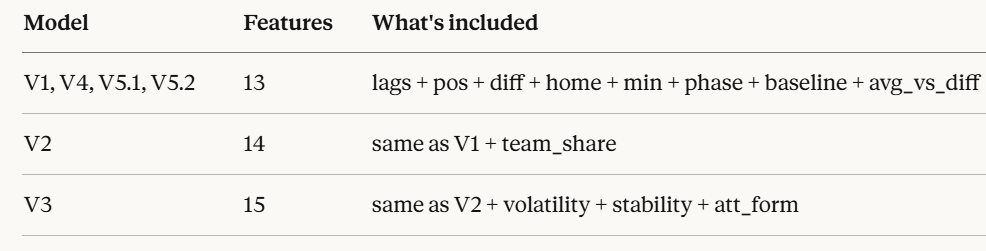

In [ ]:
# %% [Cell: Quick Squad Builder Helper - Active 2025-26 Players by Position]

# Pull the most recent GW data for active players
_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

# Get latest row per player (most recent GW)
_latest = (
    _active.sort_values('Gameweek', ascending=False)
           .drop_duplicates('Web Name', keep='first')
)

# Filter for players the FPL API confirms as available (status == 'a')
_available = _latest[
    _latest['Web Name'].apply(lambda x: live_data.get(x, {}).get('status', 'a') == 'a')
].copy()

_available['Price'] = _available['Web Name'].apply(
    lambda x: live_data.get(x, {}).get('price', 5.5)
)

# Show top 5 per position by recent avg points - these are your safest picks
for pos in ['GK', 'DEF', 'MID', 'FWD']:
    subset = _available[_available['Position'] == pos].copy()
    subset['Recent_Avg'] = subset['Web Name'].apply(
        lambda x: _active[_active['Web Name'] == x]['Total Points'].tail(5).mean()
    )
    print(f"\n--- TOP 10 {pos} (by recent 5-GW avg, status=available) ---")
    display(
        subset.nlargest(10, 'Recent_Avg')[['Web Name', 'Player Team Name', 'Price', 'Recent_Avg']]
        .reset_index(drop=True)
    )

In [ ]:
# cell 1 before 30/3

# [Cell 1: LOAD DATA + FEATURE ENGINEERING]

INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'
df = pd.read_csv(INPUT_FILE)

def enrich_features_v2(df):
    """
    Final Strategic Consolidation:
    - Ranked Deduplication (Max 2 matches per GW).
    - Season Baseline Bridge for GW1/GW2 stability.
    - Full Integrity Audit Printing.
    """

    # --- STEP 0: PRE-CLEAN ---
    df['Minutes Played'] = df['Minutes Played'].clip(upper=90)

    # --- STEP 1: RANKED DEDUPLICATION ---
    df = df.sort_values(
        ['Player UUID', 'season', 'Gameweek', 'Minutes Played', 'Total Points'],
        ascending=[True, True, True, False, False]
    )
    df = df.groupby(['Player UUID', 'season', 'Gameweek']).tail(2)

    # --- STEP 2: CHRONOLOGICAL RE-SORT ---
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # --- STEP 3: INTEGRITY AUDIT ---
    counts = df.groupby(['Player UUID', 'season', 'Gameweek']).size().reset_index(name='match_count')
    legit_dgws = counts[counts['match_count'] == 2]
    suspicious = counts[counts['match_count'] > 2]

    print(f"--- Final Integrity Audit ---")
    print(f"Legitimate DGW Match Pairs (Time-Series): {len(legit_dgws)}")
    print(f"Suspicious GWs (>2 matches): {len(suspicious)} (TARGET: 0)")
    print(f"Max Minutes in a single row: {df['Minutes Played'].max()}")

    # --- STEP 4: CORE FEATURES ---
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)

    df['Season_Phase'] = pd.cut(
        df['Gameweek'], bins=[0, 10, 19, 29, 38], labels=[1, 2, 3, 4]
    ).astype(float)

    # --- STEP 5: TEAM POINT SHARE (fully lagged, no leakage) ---
    team_col = next((c for c in ['Player Team ID', 'team', 'Player Team Name'] if c in df.columns), None)
    if team_col:
        df['_prev_individual_pts'] = df.groupby('Player UUID')['Total Points'].shift(1)
        df['_prev_team_total'] = df.groupby(
            [team_col, 'season', 'Gameweek']
        )['_prev_individual_pts'].transform('sum')

        df['Team_Point_Share'] = (
            df['_prev_individual_pts'] / df['_prev_team_total']
        ).replace([np.inf, -np.inf], 0).fillna(0)

        df.drop(columns=['_prev_individual_pts', '_prev_team_total'], inplace=True)
    else:
        df['Team_Point_Share'] = 0

    # --- STEP 6: SEASON BASELINE BRIDGE (no current-season leakage) ---
    season_stats = df.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
    season_stats.rename(columns={'Total Points': 'Season_Avg_Points'}, inplace=True)

    # shift(1) on the season axis: season N gets season N-1's completed average
    season_stats['Prev_Season_Avg_Points'] = season_stats.groupby(
        'Player UUID'
    )['Season_Avg_Points'].shift(1)

    df = df.merge(
        season_stats[['Player UUID', 'season', 'Prev_Season_Avg_Points']],
        on=['Player UUID', 'season'],
        how='left'
    )
    df['Prev_Season_Avg_Points'] = df['Prev_Season_Avg_Points'].fillna(0)

    # --- FINAL STEP: DROP ROWS WHERE NEXT MATCH CONTEXT IS UNKNOWN ---
    return df.dropna(subset=['Next_Opponent_Difficulty'])


# Run and Save
df_augmented = enrich_features_v2(df)
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')

print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")
display(df_augmented[[
    'Player Name', 'season', 'Gameweek',
    'Prev_Season_Avg_Points', 'Rolling_Avg_Minutes_5'
]].head())

In [ ]:
# Cell 5.6 Haul 30/3 with error 

# [Cell 5.6: Haul Classification — Binary Prediction + Confusion Matrix]
# FIXED: Lower threshold (6pts), haul-specific features, threshold=0.30

import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score
)

# ── 0. HAUL THRESHOLD ───────────────────────────────────────────────────────
HAUL_THRESHOLD = 6  
DECISION_THRESHOLD = 0.25  # lowered from 0.30 — model needs less confidence to call a haul

# ── 1. ADD HAUL-SPECIFIC FEATURES TO windowed_df ────────────────────────────
# We enrich the feature set specifically for classification.
# These are all lag-based so there is zero data leakage.

windowed_haul = windowed_df.copy()

# Feature 1: Did the player haul (>=6 pts) in any of the last 3 weeks?
windowed_haul['recent_haul_flag'] = (
    (windowed_haul[['lag_1', 'lag_2', 'lag_3']] >= HAUL_THRESHOLD).any(axis=1)
).astype(int)

# Feature 2: Best single score in the last 6 weeks (ceiling potential)
windowed_haul['lag_max_6'] = windowed_haul[
    [f'lag_{i}' for i in range(1, 7)]
].max(axis=1)

# Feature 3: Is the player elite? (reuse elite_mask from Cell above)
# windowed_df.index == df_augmented row indices (set in Cell 2)
elite_flag = windowed_df.index.isin(df_augmented.index[elite_mask])
windowed_haul['is_elite'] = elite_flag.astype(int)

# Feature 4: Fixture ease score (higher = easier fixture)
# next_difficulty: 1=easy, 5=hard → invert so higher = better
windowed_haul['fixture_ease'] = 6 - windowed_haul['next_difficulty']

# Feature 5: Home advantage flag (already exists as next_is_home)

# ── 2. BUILD BINARY LABELS ──────────────────────────────────────────────────
y_haul_all   = (windowed_haul['target'] >= HAUL_THRESHOLD).astype(int)
y_haul_train = y_haul_all[~global_val_mask].copy()
y_haul_val   = y_haul_all[global_val_mask].copy()

haul_feature_cols = (
    [f'lag_{i}' for i in range(1, 7)] +
    ['position', 'next_difficulty', 'next_is_home',
     'rolling_min', 'season_phase', 'season_baseline',
     'recent_haul_flag', 'lag_max_6', 'is_elite', 'fixture_ease']
)

X_haul_train = windowed_haul[~global_val_mask][haul_feature_cols].copy()
X_haul_val   = windowed_haul[global_val_mask][haul_feature_cols].copy()
X_haul_train['position'] = X_haul_train['position'].astype('category')
X_haul_val['position']   = X_haul_val['position'].astype('category')

# ── 3. CLASS IMBALANCE CHECK ────────────────────────────────────────────────
haul_rate_train = y_haul_train.mean()
haul_rate_val   = y_haul_val.mean()
spw = (1 - haul_rate_train) / haul_rate_train

print(f"Haul threshold:              >= {HAUL_THRESHOLD} pts")
print(f"Haul rate in Training set:   {haul_rate_train:.2%}  ({y_haul_train.sum()} hauls / {len(y_haul_train)} windows)")
print(f"Haul rate in Validation set: {haul_rate_val:.2%}  ({y_haul_val.sum()} hauls / {len(y_haul_val)} windows)")
print(f"scale_pos_weight:            {spw:.2f}")

# ── 4. TRAIN HAUL CLASSIFIER ────────────────────────────────────────────────
haul_params = {
    'objective':        'binary',
    'boosting_type':    'gbdt',
    'n_estimators':     1000,
    'learning_rate':    0.01,
    'max_depth':        5,
    'num_leaves':       20,
    'min_child_samples': 40,   # prevents fitting on tiny haul clusters
    'scale_pos_weight': spw,
    'reg_alpha':        0.5,
    'reg_lambda':       0.5,
    'verbosity':        -1,
    'random_state':     42
}

print("\nTraining Haul Classifier (v2 — enriched features)...")
haul_clf = lgb.LGBMClassifier(**haul_params)
haul_clf.fit(
    X_haul_train, y_haul_train,
    eval_set=[(X_haul_val, y_haul_val)],
    categorical_feature=['position'],
    callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False),
               lgb.log_evaluation(period=200)]
)

# ── 5. PREDICT ───────────────────────────────────────────────────────────────
haul_proba = haul_clf.predict_proba(X_haul_val)[:, 1]
haul_pred  = (haul_proba >= DECISION_THRESHOLD).astype(int)

# ── 6. CONFUSION MATRIX + PRECISION/RECALL CURVE ────────────────────────────
cm = confusion_matrix(y_haul_val, haul_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['No Haul', 'Haul'],
    yticklabels=['No Haul', 'Haul']
)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual',    fontsize=12)
axes[0].set_title(f'Confusion Matrix  (haul ≥ {HAUL_THRESHOLD} pts, cutoff = {DECISION_THRESHOLD})', fontsize=12)

thresholds = np.arange(0.10, 0.71, 0.05)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    p_t = (haul_proba >= t).astype(int)
    if p_t.sum() == 0:
        precisions.append(0); recalls.append(0); f1s.append(0)
        continue
    precisions.append(precision_score(y_haul_val, p_t, zero_division=0))
    recalls.append(recall_score(y_haul_val,    p_t, zero_division=0))
    f1s.append(f1_score(y_haul_val,            p_t, zero_division=0))

axes[1].plot(thresholds, precisions, label='Precision', color='#003f5c', linewidth=2.5, marker='o')
axes[1].plot(thresholds, recalls,    label='Recall',    color='#ff7c43', linewidth=2.5, marker='s')
axes[1].plot(thresholds, f1s,        label='F1',        color='#2ca02c', linewidth=2,   linestyle='--')
axes[1].axvline(x=DECISION_THRESHOLD, color='gray', linestyle=':', linewidth=1.5,
                label=f'Chosen threshold ({DECISION_THRESHOLD})')
axes[1].set_xlabel('Decision Threshold (probability)', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Precision / Recall Trade-off by Threshold', fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 7. METRICS REPORT ────────────────────────────────────────────────────────
precision_haul = precision_score(y_haul_val, haul_pred, zero_division=0)
recall_haul    = recall_score(y_haul_val,    haul_pred, zero_division=0)
f1_haul        = f1_score(y_haul_val,        haul_pred, zero_division=0)
auc_haul       = roc_auc_score(y_haul_val,   haul_proba)

print("\n" + "=" * 55)
print("  HAUL CLASSIFIER — PERFORMANCE REPORT")
print("=" * 55)
print(f"Haul threshold:   >= {HAUL_THRESHOLD} points")
print(f"Decision cutoff:  {DECISION_THRESHOLD} probability")
print("-" * 55)
print(f"True Positives  (correct haul calls):    {tp}")
print(f"False Positives (wrong haul calls):      {fp}  ← minimise this")
print(f"True Negatives  (correct non-haul):      {tn}")
print(f"False Negatives (missed hauls):          {fn}")
print("-" * 55)
print(f"Precision:  {precision_haul:.4f}")
print(f"Recall:     {recall_haul:.4f}")
print(f"F1 Score:   {f1_haul:.4f}")
print(f"ROC-AUC:    {auc_haul:.4f}")
print("=" * 55)

#if precision_haul >= 0.60:
   # print("Precision >= 0.60: When the model says HAUL — trust it.")
#elif precision_haul >= 0.40:
   # print("Precision 0.40–0.60: Moderate confidence. Review the curve")
   # print("above and consider adjusting DECISION_THRESHOLD.")
#else:
   # print("Precision < 0.40: Still too many false alarms.")
  #  print("Try raising DECISION_THRESHOLD to 0.35 or 0.40.")

if precision_haul >= 0.40:
    print("[SUCCESS] Precision is adequate. When the model flags a haul, it is a strong captaincy candidate.")
else:
    print("[WARNING] Precision is low. The model is flagging too many False Positives.")
    print("Consider raising DECISION_THRESHOLD by 0.01 to tighten the filter.")

# ── 8. TOP PREDICTED HAULERS FOR NEXT GW ────────────────────────────────────
print(f"\n--- TOP 10 PREDICTED HAULERS FOR GW {CURRENT_GW} ---")
print(f"(Players the classifier is most confident will score >= {HAUL_THRESHOLD} pts)")

# Build haul features for the inference snapshot (current season players)
inf_haul = inference_df.copy()   # inference_df built in the leaderboard cell

# Add the same engineered features
inf_haul['recent_haul_flag'] = (
    (inf_haul[['lag_1', 'lag_2', 'lag_3']] >= HAUL_THRESHOLD).any(axis=1)
).astype(int)
inf_haul['lag_max_6']    = inf_haul[[f'lag_{i}' for i in range(1, 7)]].max(axis=1)
inf_haul['fixture_ease'] = 6 - inf_haul['next_difficulty']

# is_elite: map from player name to seasonal avg
elite_name_set = set(df_augmented[elite_mask]['Web Name'].unique())
inf_haul['is_elite'] = [1 if n in elite_name_set else 0 for n in player_names]

inf_haul_features = inf_haul[haul_feature_cols].copy()
inf_haul_features['position'] = inf_haul_features['position'].astype('category')

haul_proba_gw = haul_clf.predict_proba(inf_haul_features)[:, 1]

hauler_board = pd.DataFrame({
    'Player':         player_names,
    'Haul_Prob (%)':  np.round(haul_proba_gw * 100, 1),
    'Pred_Pts (reg)': np.round(raw_preds, 2)
}).sort_values('Haul_Prob (%)', ascending=False)

display(hauler_board.head(10))

# ── 9. SAVE ───────────────────────────────────────────────────────────────────
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
haul_clf.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_haul_classifier.txt'))
hauler_board.to_csv(
    PRO_OUTPUT_DIR / f'fpl_haul_predictions_GW{CURRENT_GW}.csv',
    index=False, encoding='utf-8-sig'
)

# Store globally for use in audit table and UI cells
globals()['haul_clf']          = haul_clf
globals()['haul_proba_gw']     = haul_proba_gw
globals()['hauler_board']      = hauler_board
globals()['precision_haul']    = precision_haul
globals()['recall_haul']       = recall_haul
globals()['f1_haul']           = f1_haul
globals()['auc_haul']          = auc_haul
globals()['HAUL_THRESHOLD']    = HAUL_THRESHOLD
globals()['DECISION_THRESHOLD']= DECISION_THRESHOLD

print(f"\nSaved: fpl_haul_classifier.txt")
print(f"Saved: fpl_haul_predictions_GW{CURRENT_GW}.csv") 

In [ ]:
# %% [Cell: Smart Transfer Advice - High-ROI Single Swaps]
import pandas as pd
from IPython.display import display

def suggest_smart_transfers(my_squad, threshold_pct=10.0, free_transfers=1):
    """
    free_transfers: how many free transfers you currently have (default 1).
    Each transfer beyond the free allowance costs -4 points.
    The improvement must exceed the hit cost to be recommended.
    """
    if not my_squad:
        print("[WARNING] Build your squad in the UI Hub first.")
        return

    xp_col = player_pool.columns[1] 
    current_df = player_pool[player_pool['Player'].isin(my_squad)].copy()
    market_df = player_pool[~player_pool['Player'].isin(my_squad)].copy()
    
    # Filter for healthy players
    market_df['Status'] = market_df['Player'].map(lambda x: live_data.get(x, {}).get('status', 'a'))
    market_df = market_df[market_df['Status'] == 'a']

    recommendations = []

    # Calculate the hit cost for a SINGLE transfer once, outside the loop.
    hit_cost = 0 if free_transfers >= 1 else 4

    for _, current_p in current_df.iterrows():
        # Find the single best replacement for THIS player in the same position
        best_replacement = market_df[market_df['Pos_ID'] == current_p['Pos_ID']].sort_values(xp_col, ascending=False).head(1)
        
        if best_replacement.empty:
            continue
            
        target_p = best_replacement.iloc[0]
        xp_gain = target_p[xp_col] - current_p[xp_col]
        
        # Calculate Improvement %
        if current_p[xp_col] <= 0:
            pct_improvement = 100.0 if xp_gain > 0 else 0.0
        else:
            pct_improvement = (xp_gain / current_p[xp_col]) * 100
        
        net_gain = xp_gain - hit_cost

        # Apply Strict FPL Tiered Logic based on Free vs Hit
        if hit_cost == 0:
            # For Free Transfers, a +1.5 point gain is an excellent upgrade
            if net_gain >= 1.5:
                action = f"[SWAP] STRONG (+{net_gain:.1f} net pts for FREE)"
            elif net_gain > 0.0:
                action = f"[BORDERLINE] MARGINAL (+{net_gain:.1f} net pts for FREE)"
            else:
                action = f"[HOLD] NOT WORTH IT ({net_gain:.1f} net pts)"
        else:
            # If taking a -4 Hit, you need massive expected profit to justify it
            if net_gain >= 2.0:  # Meaning the raw xP gain was > 6.0
                action = f"[SWAP] STRONG (+{net_gain:.1f} profit after -{hit_cost} hit)"
            elif net_gain > 0.0:
                action = f"[BORDERLINE] RISKY HIT (+{net_gain:.1f} profit after -{hit_cost} hit)"
            else:
                action = f"[HOLD] NEVER TAKE HIT ({net_gain:.1f} net pts)"

        # Only append if it meets the minimum percentage boost threshold
        if pct_improvement >= threshold_pct:
            recommendations.append({
                'Player': current_p['Player'],
                'Action': action,
                'Best Replacement': target_p['Player'],
                'Current xP': round(float(current_p[xp_col]), 2),
                'Target xP': round(float(target_p[xp_col]), 2),
                'xP Gain': round(float(xp_gain), 2),
                '% Boost': round(float(pct_improvement), 1),
                'Price Diff': round(float(target_p['Price'] - current_p['Price']), 1)
            })

    # Display results
    rec_df = pd.DataFrame(recommendations)
    
    print("=" * 85)
    print(f" STRATEGIC TRANSFER AUDIT (Min Threshold: {threshold_pct}%)")
    print("=" * 85)

    if not rec_df.empty:
        # Sort by xP Gain to show the biggest potential moves first
        rec_df = rec_df.sort_values('xP Gain', ascending=False)
        display(rec_df)
        
        # Filter for Strong Swaps to provide a definitive recommendation
        strong_swaps = rec_df[rec_df['Action'].str.contains("STRONG")]
        if not strong_swaps.empty:
            top_move = strong_swaps.iloc[0]
            print(f"\n[PRO ADVICE] Recommended move: {top_move['Player']} -> {top_move['Best Replacement']}.")
        else:
            print("\n[PRO ADVICE] No transfers meet the >1.5 net point threshold. HOLD your team.")
    else:
        print("No players found meeting the criteria.")

# Run the advice engine (assuming 1 Free Transfer)
suggest_smart_transfers(my_selection, threshold_pct=10.0, free_transfers=1)

In [ ]:
# %% [Cell: Smart Transfer Advice - 3-GW Horizon Engine]
import pandas as pd
import numpy as np
from IPython.display import display

def suggest_smart_transfers_3gw(my_squad, free_transfers=1):
    """
    Evaluates transfers across a 3-Gameweek Horizon using the winning 3-GW model.
    A -4 hit is evaluated against 3 weeks of expected returns.
    """
    if not my_squad:
        print("[WARNING] Build your squad in the UI Hub first.")
        return
    
    if 'winning_3gw_model' not in globals() or 'winning_3gw_feats' not in globals():
        print("[ERROR] 3-GW Model not found. Run the 3-GW Leaderboard cell first.")
        return

    print("Generating live 3-Week Projections...")
    
    # 1. BUILD LIVE INFERENCE DATA FOR 3-GW MODEL
    active_players = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
    inf_list = []
    names = []

    for pid, group in active_players.groupby('Player UUID'):
        group = group.sort_values('Gameweek')
        if len(group) >= 6:
            lags = list(group['Total Points'].tail(6).values)
            last = group.iloc[-1]
            
            row_dict = {f'lag_{i}': lags[6-i] for i in range(6, 0, -1)}
            row_dict['position'] = last['Position']
            row_dict['next_difficulty'] = last['Next_Opponent_Difficulty']
            row_dict['next_is_home'] = last['Next_Is_Home']
            row_dict['rolling_min'] = last['Rolling_Avg_Minutes_5']
            row_dict['season_phase'] = last['Season_Phase']
            row_dict['season_baseline'] = last['Prev_Season_Avg_Points']
            row_dict['fdi_3gw'] = last['FDI_3GW']
            row_dict['volatility'] = last['Points_Volatility_5']
            row_dict['stability'] = last['Min_Stability_5']
            row_dict['att_form'] = last['Attacking_Form_3']
            row_dict['team_share'] = last['Team_Point_Share']
            
            inf_list.append(row_dict)
            names.append(last['Web Name'])

    inf_df = pd.DataFrame(inf_list)
    # Safety: if winning model uses standard features (no volatility/stability),
    # drop those columns before predicting to avoid shape mismatch
    available_feats = [f for f in winning_3gw_feats if f in inf_df.columns]
    missing_feats = [f for f in winning_3gw_feats if f not in inf_df.columns]
    if missing_feats:
        print(f"[WARNING] Missing features for 3-GW model: {missing_feats}")
        print("These will be filled with 0. Check that Cell 15 V3 enrichment has run.")
        for f in missing_feats:
            inf_df[f] = 0

    inf_df = inf_df[winning_3gw_feats].copy()
    if 'position' in inf_df.columns:
        inf_df['position'] = inf_df['position'].astype('category')
        
    # 2. GENERATE 3-WEEK PREDICTIONS
    preds_3gw = winning_3gw_model.predict(inf_df)
    
    pool_3gw = pd.DataFrame({'Player': names, 'Pred_3GW': preds_3gw})
    pool_3gw['Price'] = pool_3gw['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    pool_3gw['Pos_ID'] = pool_3gw['Player'].map(pos_map).map({'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}).fillna(3).astype(int)
    pool_3gw['Status'] = pool_3gw['Player'].map(lambda x: live_data.get(x, {}).get('status', 'a'))

    # 3. TRANSFER LOGIC
    current_df = pool_3gw[pool_3gw['Player'].isin(my_squad)].copy()
    market_df = pool_3gw[(~pool_3gw['Player'].isin(my_squad)) & (pool_3gw['Status'] == 'a')].copy()

    recommendations = []
    hit_cost = 0 if free_transfers >= 1 else 4

    for _, current_p in current_df.iterrows():
        # Find best replacement in the same position
        best_replacement = market_df[market_df['Pos_ID'] == current_p['Pos_ID']].sort_values('Pred_3GW', ascending=False).head(1)
        
        if best_replacement.empty:
            continue
            
        target_p = best_replacement.iloc[0]
        xp_gain_3gw = target_p['Pred_3GW'] - current_p['Pred_3GW']
        net_gain = xp_gain_3gw - hit_cost

        # Strict FPL Tiered Logic (Scaled for 3 weeks)
        # We look for a net gain over 3 weeks that is worth the structural change
        if hit_cost == 0:
            if net_gain >= 3.0:
                action = f"[SWAP] STRONG (+{net_gain:.1f} net pts over 3GW for FREE)"
            elif net_gain > 0.0:
                action = f"[BORDERLINE] MARGINAL (+{net_gain:.1f} net pts over 3GW for FREE)"
            else:
                action = f"[HOLD] NOT WORTH IT ({net_gain:.1f} net pts over 3GW)"
        else:
            if net_gain >= 2.5: 
                action = f"[SWAP] STRONG (+{net_gain:.1f} profit over 3GW after -{hit_cost} hit)"
            elif net_gain > 0.0:
                action = f"[BORDERLINE] RISKY HIT (+{net_gain:.1f} profit over 3GW after -{hit_cost} hit)"
            else:
                action = f"[HOLD] NEVER TAKE HIT ({net_gain:.1f} net pts over 3GW)"

        recommendations.append({
            'Player': current_p['Player'],
            'Action': action,
            'Best Replacement': target_p['Player'],
            'Current 3GW xP': round(float(current_p['Pred_3GW']), 2),
            'Target 3GW xP': round(float(target_p['Pred_3GW']), 2),
            '3GW Gain': round(float(xp_gain_3gw), 2),
            'Price Diff': round(float(target_p['Price'] - current_p['Price']), 1)
        })

    rec_df = pd.DataFrame(recommendations)
    
    print("\n" + "=" * 85)
    print(f" STRATEGIC TRANSFER AUDIT (3-GAMEWEEK HORIZON)")
    print("=" * 85)

    if not rec_df.empty:
        rec_df = rec_df.sort_values('3GW Gain', ascending=False)
        display(rec_df)
        
        strong_swaps = rec_df[rec_df['Action'].str.contains("STRONG")]
        if not strong_swaps.empty:
            top_move = strong_swaps.iloc[0]
            print(f"\n[PRO ADVICE] Top 3-Week Target: Swap {top_move['Player']} -> {top_move['Best Replacement']}.")
        else:
            print("\n[PRO ADVICE] No transfers meet the 3-GW structural upgrade threshold. HOLD your team.")
    else:
        print("No players found meeting the criteria.")

# Run the advice engine (assuming 1 Free Transfer)
suggest_smart_transfers_3gw(my_selection, free_transfers=1)